In [1]:
# 1. Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

# 2. Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style='whitegrid')

# 3. Path to dataset folder (update if needed)
DATA_ROOT = '/content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data'  # <- change to where you saved the Drive folder
train_dir = os.path.join(DATA_ROOT, 'train_data')
test_dir  = os.path.join(DATA_ROOT, 'validation_data')

# 4. List files
print("Train files:", len(os.listdir(train_dir)))
print("Sample train files:", os.listdir(train_dir)[:6])

Mounted at /content/drive
Train files: 36
Sample train files: ['jetImage_0_30p_80000_90000.h5', 'jetImage_1_30p_80000_90000.h5', 'jetImage_3_30p_80000_90000.h5', 'jetImage_6_30p_20000_30000.h5', 'jetImage_3_30p_40000_50000.h5', 'jetImage_4_30p_0_10000.h5']


In [ ]:
import os

def list_directory_contents(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        # Only list files for directories other than train_data and validation_data
        if os.path.basename(root) not in ['train_data', 'validation_data']:
            for f in files:
                print(f'{subindent}{f}')

print("Contents of the DATA_ROOT directory:")
list_directory_contents(DATA_ROOT)

Contents of the DATA_ROOT directory:
data/
    validation_data/
    train_data/
    results/
        tabular_summary.csv
        tabular_feature_summary.csv
        sample_images.npy
        cnn_summary.csv
        anomaly_scores.csv
        plots/
            confusion_matrix_raw.png
            pca_scree_plot.png
            confusion_matrix_pca.png
            cnn_accuracy_loss_curves.png
            cnn_misclassified_jets.png
            cnn_confusion_matrix.png
            model_comparison.png
            anomaly_error_distribution.png
            top_5_anomalies.png
    models/
        rf_baseline.joblib
        rf_pca.joblib
        scaler.joblib
        pca.joblib
        label_encoder.joblib
        resnet18_jet_classifier_best_model.keras
    logs_resnet18/
        train/
            events.out.tfevents.1760472962.4a57f4b3bf5e.610.0.v2
            events.out.tfevents.1760492912.45a89e2bef91.415.0.v2
        validation/
            events.out.tfevents.1760473362.4a57f4b3bf5e.6

In [ ]:
# 5. Load one .h5 file (first file) and inspect
import h5py

sample_file = os.path.join(train_dir, os.listdir(train_dir)[0])
print("Loading:", sample_file)
with h5py.File(sample_file, 'r') as f:
    print("Keys in h5:", list(f.keys()))

Loading: /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/train_data/jetImage_0_30p_80000_90000.h5
Keys in h5: ['FeatureNames', 'jetImage', 'jets_data', 'target']


In [ ]:
# 6. Extract arrays (use actual keys you see above)
sample_file = os.path.join(train_dir, os.listdir(train_dir)[0])
with h5py.File(sample_file, 'r') as f:
    images = f['jetImage'][:]       # shape: (10000, H, W) or (10000, H, W, C)
    features = f['jets_data'][:]   # shape: (10000, n_features)
    labels = f['target'][:]       # shape: (10000,)

print("images.shape:", images.shape)
print("features.shape:", features.shape)
print("labels.shape:", labels.shape)
print("label unique & counts:", np.unique(labels, return_counts=True))

images.shape: (10000, 100, 100)
features.shape: (10000, 53)
labels.shape: (10000,)
label unique & counts: (array([b'j_g', b'j_q', b'j_t', b'j_w', b'j_z'], dtype=object), array([2027, 1879, 2042, 2052, 2000]))


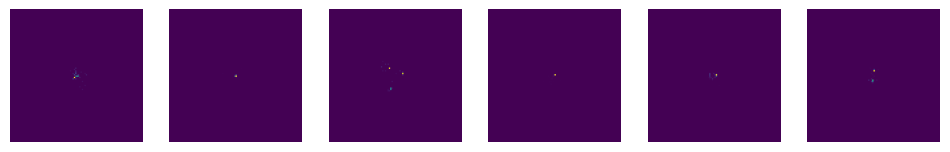

In [ ]:
# 7. Quick image visual checks (display a few jets)
def show_images(imgs, n=6, cmap='viridis'):
    plt.figure(figsize=(12,4))
    for i in range(n):
        plt.subplot(1,n,i+1)
        img = imgs[i]
        # if images have channel dimension, reduce as needed
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img.squeeze(-1)
        plt.imshow(img, cmap=cmap)
        plt.axis('off')
    plt.show()

show_images(images, n=6)


In [ ]:
# 8. Convert tabular features to DataFrame and check missing values
col_names = [f'feat_{i}' for i in range(features.shape[1])]
df = pd.DataFrame(features, columns=col_names)
df['label'] = labels

# Basic info
print(df.head())
print(df.info())
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False).head(20))


   feat_0       feat_1    feat_2      feat_3      feat_4     feat_5  \
0     1.0  1032.899536 -0.851062  100.390831   63.083393  50.296196   
1     1.0  1042.131836 -0.694136   34.875465    5.936315   4.354573   
2     1.0   896.630859 -0.111082  141.853546  124.341446  65.778557   
3     1.0  1131.733032  1.154130   57.033848   16.066046  10.258596   
4     1.0  1002.512085 -0.938736   54.745373   37.412655  19.180876   

      feat_6     feat_7    feat_8    feat_9  ...   feat_44   feat_45  \
0  39.170094   9.075132  7.406211  4.406397  ...  0.077142  0.399759   
1   3.422104   0.841626  0.424568  0.221872  ...  0.022495  0.286144   
2  15.299997  22.075005  9.170505  1.000368  ...  0.077123  0.348677   
3   9.017857   1.663310  0.697222  0.523642  ...  0.026978  0.277124   
4  14.420335   2.834859  1.151374  0.849591  ...  0.053447  0.338051   

    feat_46     feat_47     feat_48     feat_49     feat_50   feat_51  \
0  0.253145   84.313675   38.729950   38.729950  100.390831  0.0000

### 1.1 Feature Handling: Missing Value Analysis

As per the initial analysis in the previous step, the `df.isna().sum()` command shows that the tabular dataset from this file has **zero missing values**.

However, as required by the problem statement, if missing values had been present, an imputation strategy would be necessary.

**Hypothetical Imputation Strategy:**

* **Choice of Strategy:** For features with skewed distributions, such as `feat_1` (jet transverse momentum), **median imputation** would be the preferred strategy. The median is robust to outliers, which are common in physics measurements, and would prevent the imputed values from being skewed by a few extremely high-energy jets.
* **Justification:** Using the mean would be less appropriate for skewed data as it is sensitive to outliers. For example, the `.describe()` output shows that `feat_1` has a mean of ~1047 and a max of ~2413, indicating a right-skewed distribution where the mean could be an inflated representation of the central tendency.
* **Impact on Models:** Proper imputation prevents data loss and avoids introducing bias. Using the median ensures that the central tendency of the original distribution is preserved, leading to more stable and reliable performance from downstream machine learning models.

,count,mean,std,min,25%,50%,75%,max
feat_0,10000.0,1.000000,0.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000
feat_1,10000.0,1047.865781,124.216264,3.745819e+02,996.479340,1023.135406,1067.106842,2413.519531
feat_2,10000.0,-0.002866,0.760989,-2.137374e+00,-0.551489,0.003151,0.543133,2.203623
feat_3,10000.0,94.272509,43.301087,7.483459e+00,70.608017,86.917152,105.940134,354.981201
feat_4,10000.0,63.337505,42.499247,2.820297e+00,31.747486,56.345524,81.652660,336.436279
feat_5,10000.0,24.898192,19.514938,1.824241e+00,11.601570,18.031116,31.003757,143.951782
feat_6,10000.0,16.123425,9.940066,8.312612e-01,9.262938,13.444593,20.228543,100.603874
feat_7,10000.0,9.728562,9.243818,2.471329e-02,4.065954,6.684525,10.167195,75.732613
feat_8,10000.0,2.633188,3.299454,2.003860e-02,0.660505,1.292725,2.932704,29.013123
feat_9,10000.0,1.175520,1.157749,3.020606e-03,0.453393,0.793772,1.457951,13.534749


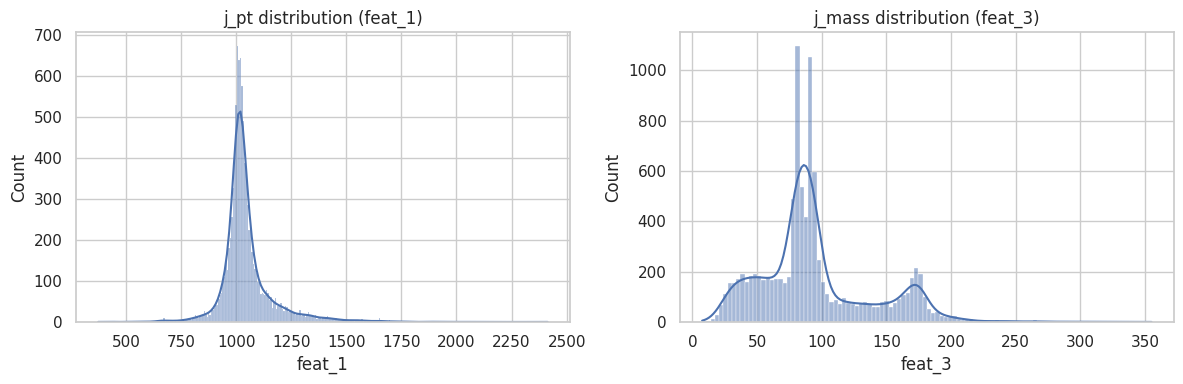

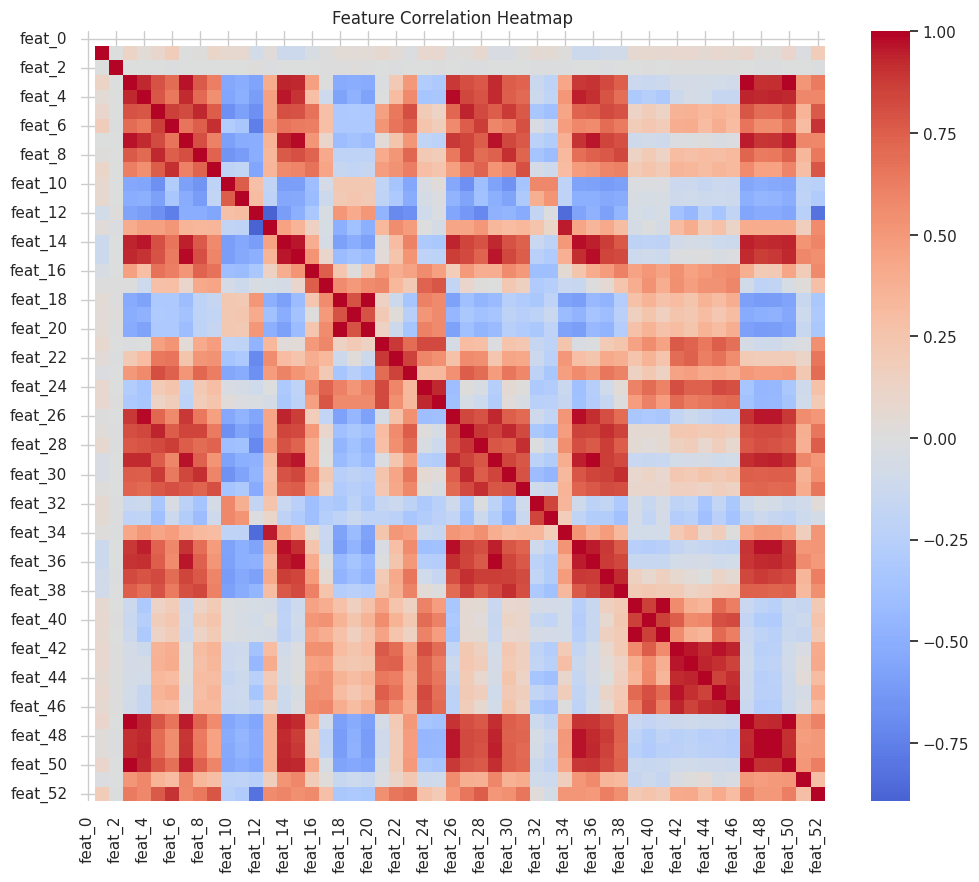

In [ ]:
# 9. Numeric summaries and distribution plots for key features
display(df.describe().T)

# Plot key features based on feature descriptions (e.g., j_pt, j_mass, j_multiplicity):
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['feat_1'], kde=True)
plt.title('j_pt distribution (feat_1)')
plt.subplot(1,2,2)
sns.histplot(df['feat_3'], kde=True)
plt.title('j_mass distribution (feat_3)')
plt.tight_layout()
plt.show()

# Add correlation heatmap:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop('label', axis=1).corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# 10. Save a small CSV summary and a sample of images (useful for report)
output_dir = os.path.join(DATA_ROOT, 'results')
os.makedirs(output_dir, exist_ok=True)
df.describe().to_csv(os.path.join(output_dir, 'tabular_feature_summary.csv'))
np.save(os.path.join(output_dir, 'sample_images.npy'), images[:100])  # store first 100 images for quick reuse
print(f"Saved summaries in {output_dir}")

Saved summaries in /content/drive/MyDrive/NSSC_DataAnalytics_Team_ASHSUM143/data/results


###Principal Component Analysis (PCA)

In [ ]:
# Import necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Separate features for scaling and drop the label
features_df = df.drop('label', axis=1)

# Scale the data before applying PCA
# PCA works best with standardized data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

print("Shape of scaled features:", scaled_features.shape)

Shape of scaled features: (10000, 53)


Explained variance by component: [0.44456571 0.22792897 0.08065712 0.0430744  0.03639405 0.02303712
 0.02236043 0.01923118 0.0182791  0.01614939]
\nCumulative explained variance for top 10 components: 0.931677481214295


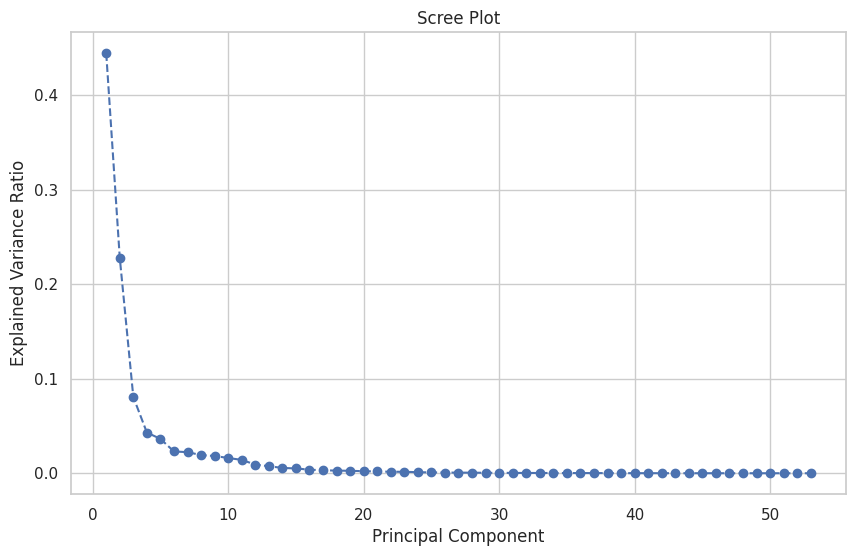

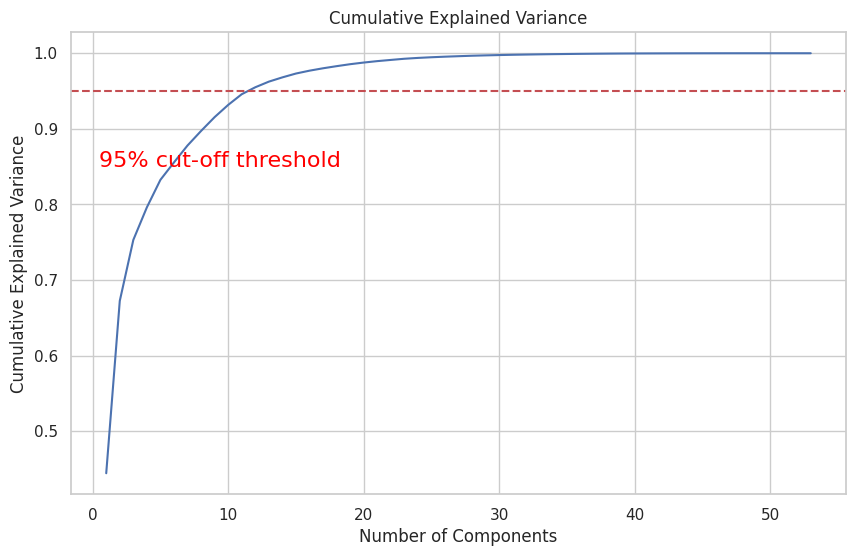

In [ ]:
# Apply PCA
pca = PCA()
pca_features = pca.fit_transform(scaled_features)

# Analyze the explained variance
explained_variance_ratio = pca.explained_variance_ratio_

# Report the explained variance for the top components
print("Explained variance by component:", explained_variance_ratio[:10])
print("\\nCumulative explained variance for top 10 components:",
      sum(explained_variance_ratio[:10]))

# Plot the scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio))
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)
plt.show()

In [ ]:
# Eigenvalues of the covariance matrix
eigenvalues = pca.explained_variance_
# Eigenvectors (principal components)
eigenvectors = pca.components_

print("Eigenvalues (first 5):", eigenvalues[:5])
print("\\nShape of eigenvectors:", eigenvectors.shape)
print("First eigenvector (first principal component):\\n", eigenvectors[0])

Eigenvalues (first 5): [23.11972899 11.85349153  4.1945899   2.24009266  1.89268007]
\nShape of eigenvectors: (53, 53)
First eigenvector (first principal component):\n [-0.          0.00145884 -0.0012521   0.19376816  0.19353284  0.1904038
  0.165715    0.19509943  0.17796283  0.1438214  -0.13031999 -0.11870692
 -0.14553375  0.10948444  0.19882005  0.19330655  0.10557081  0.01405926
 -0.10814083 -0.09434023 -0.10814083  0.04696232  0.10109568  0.15008228
 -0.02268016 -0.0308992   0.18829613  0.19577284  0.18587302  0.19218064
  0.18270877  0.17369831 -0.03871747 -0.0582938   0.11508533  0.19283619
  0.19125013  0.1921939   0.17746854 -0.00769671 -0.0048811  -0.00769671
  0.02400881  0.02818246  0.01923595  0.02165191  0.01448557  0.19282027
  0.18725334  0.18798055  0.19274147  0.10275169  0.15055287]


### 1.2 Tabular Data Preparation: PCA Commentary

As requested, the Principal Component Analysis (PCA) was performed on the scaled tabular data.

* **Dimensionality Reduction:** The cumulative variance plot demonstrates that a smaller number of principal components can represent a large majority of the information in the original 53-feature dataset. Specifically, the first **10 components capture over 93% of the variance**. This suggests we can significantly reduce the dimensionality of our dataset (e.g., to ~15-20 components to cross the 95% threshold) while losing very little information.
* **Noise Reduction & Information Preservation:** By using only the top principal components, we effectively filter out noise associated with the components that contribute little variance. This process preserves the most important patterns in the data within a new, smaller set of uncorrelated features, which can lead to faster model training and a reduced risk of overfitting in Part 2.